# Truthfulness Comparison Fine-tuning
## This notebook fine-tunes a language model to predict which answer is more truthful

In [1]:
# %% 
# Install required packages (run once)  
!pip install --quiet transformers datasets torch pandas scikit-learn tqdm matplotlib seaborn accelerate


[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 24/24 [03:26<00:00,  8.59s/it]


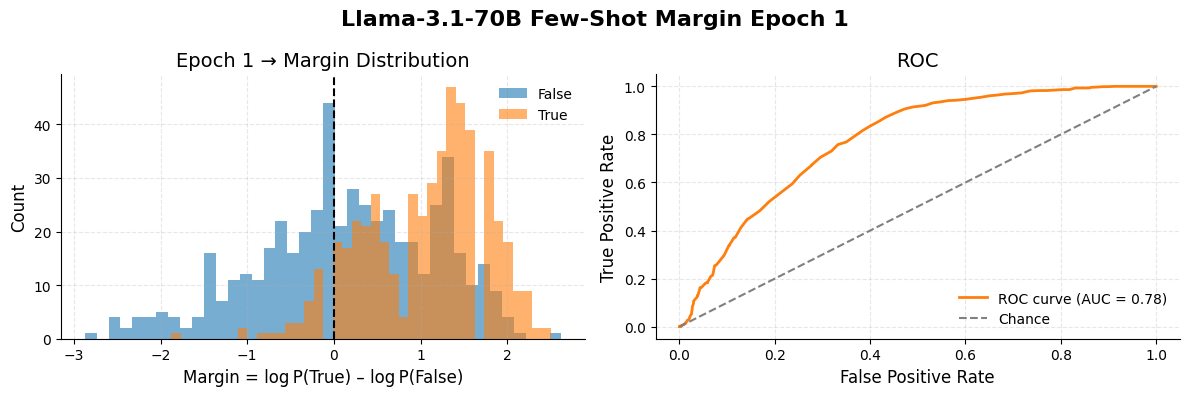

Epoch 1: trained on 8 samples → loss=0.2678


100%|██████████| 24/24 [03:25<00:00,  8.55s/it]


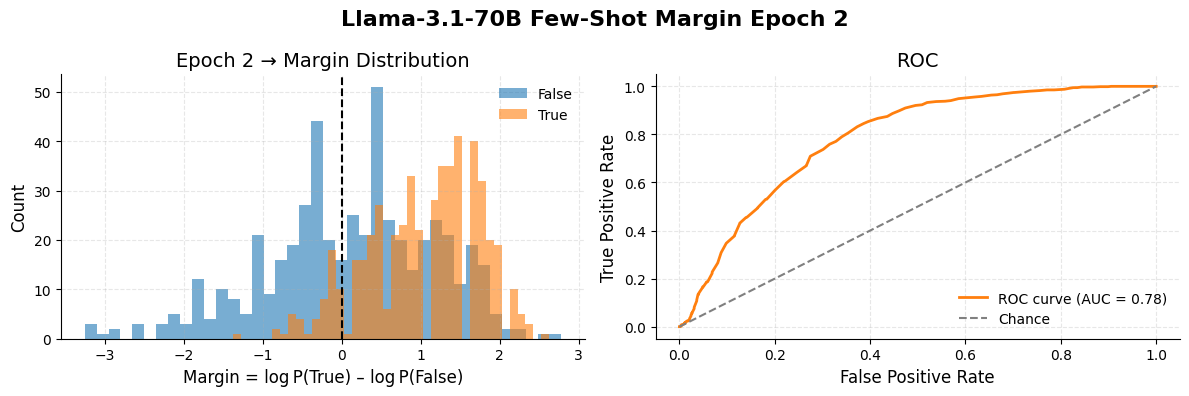

Epoch 2: trained on 8 samples → loss=0.3221


100%|██████████| 24/24 [03:25<00:00,  8.55s/it]


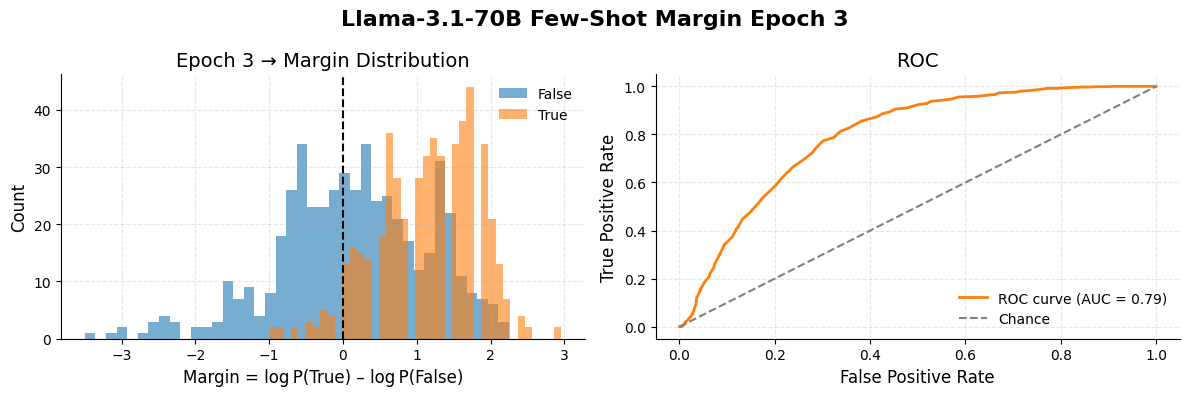

Epoch 3: trained on 8 samples → loss=0.1594


100%|██████████| 24/24 [03:24<00:00,  8.53s/it]


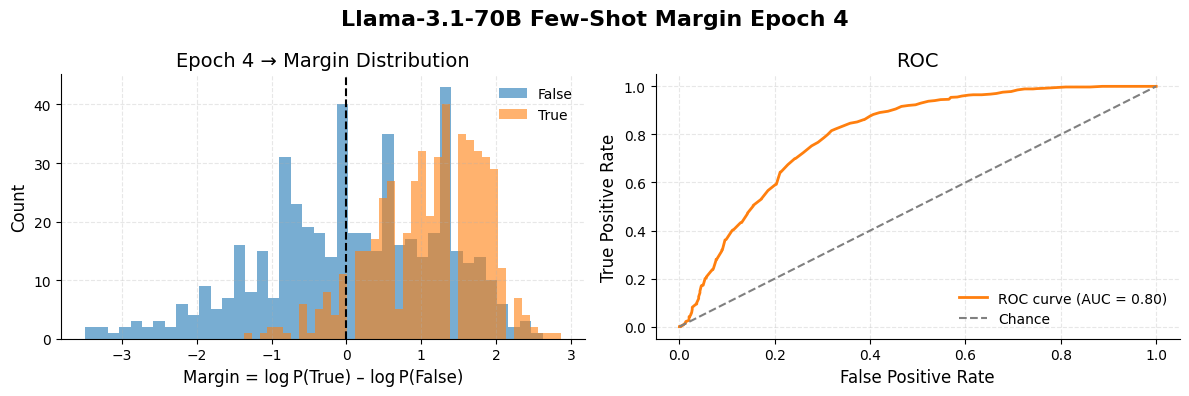

Epoch 4: trained on 8 samples → loss=0.2908


100%|██████████| 24/24 [03:25<00:00,  8.55s/it]


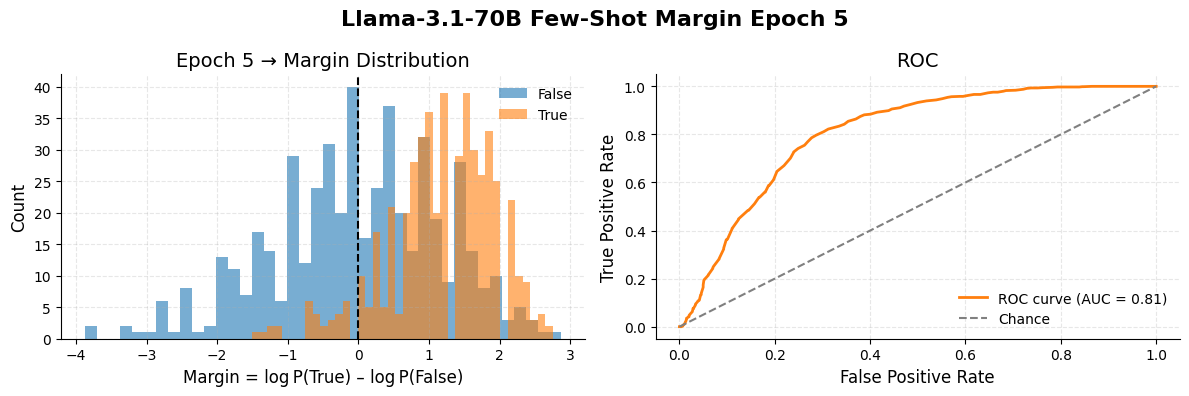

Epoch 5: trained on 8 samples → loss=0.1135


100%|██████████| 24/24 [03:24<00:00,  8.52s/it]


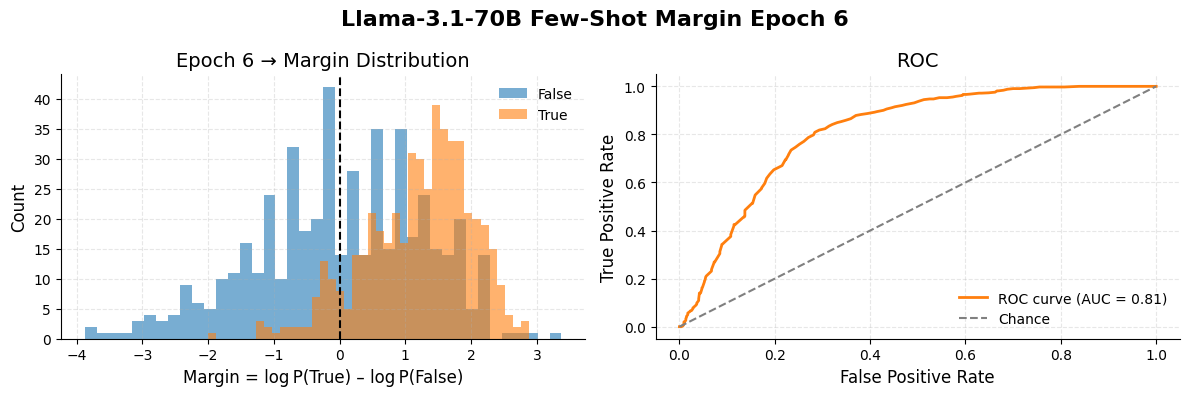

Epoch 6: trained on 8 samples → loss=0.0999


100%|██████████| 24/24 [03:24<00:00,  8.53s/it]


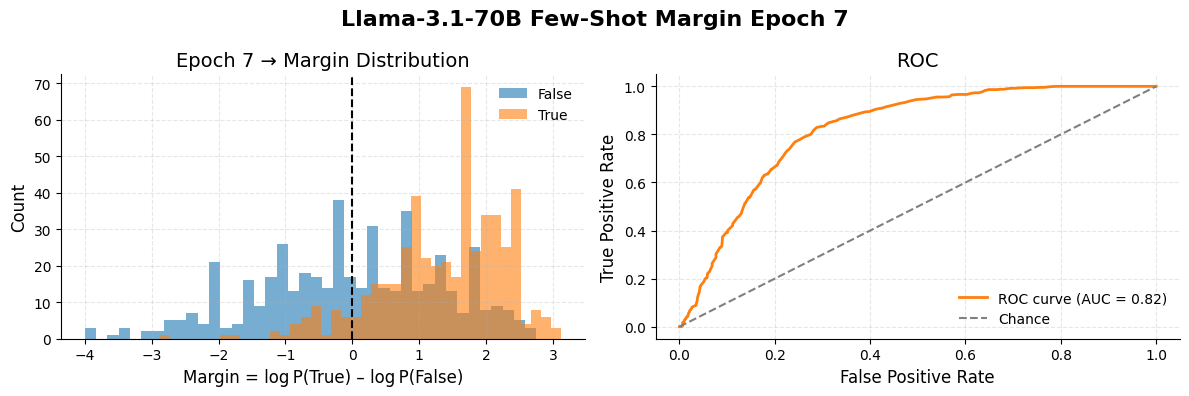

Epoch 7: trained on 8 samples → loss=0.0911


100%|██████████| 24/24 [03:25<00:00,  8.54s/it]


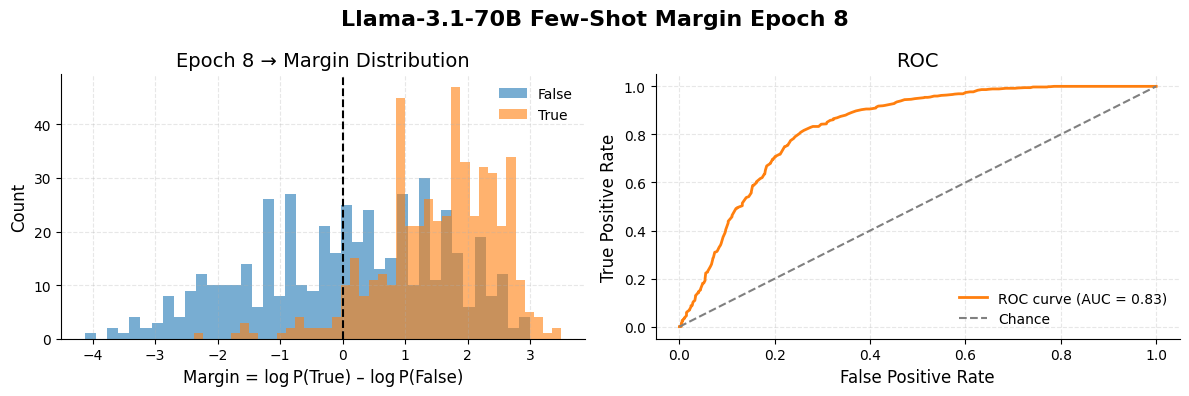

Epoch 8: trained on 8 samples → loss=0.0462


100%|██████████| 24/24 [03:25<00:00,  8.56s/it]


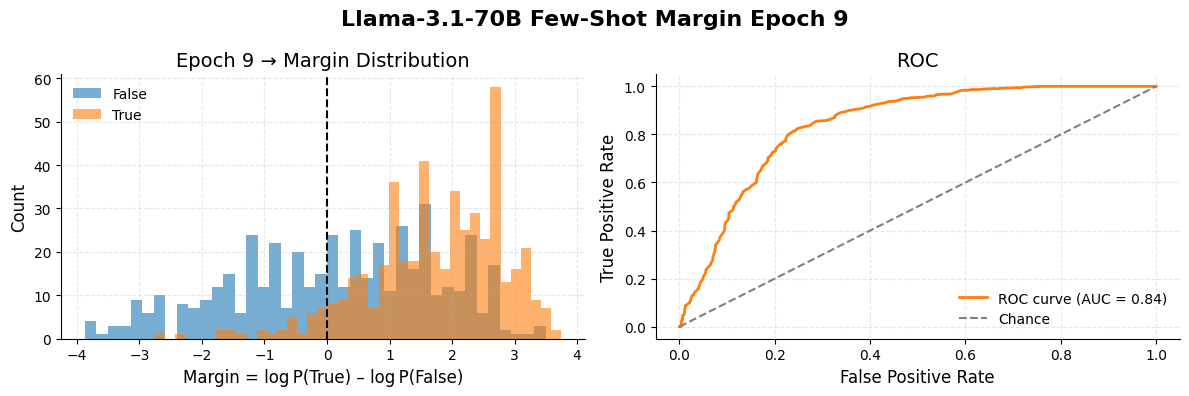

Epoch 9: trained on 8 samples → loss=0.0348


100%|██████████| 24/24 [03:24<00:00,  8.54s/it]


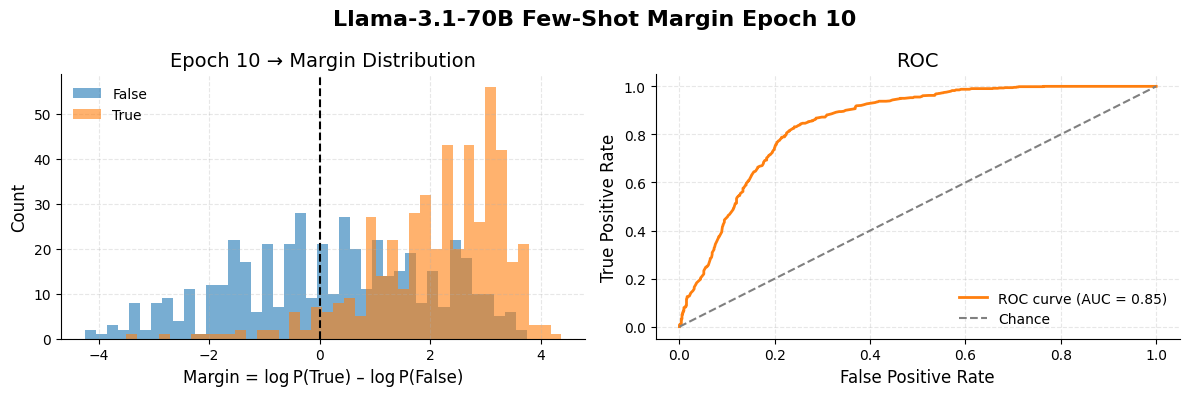

Epoch 10: trained on 8 samples → loss=0.0101


100%|██████████| 24/24 [03:24<00:00,  8.54s/it]


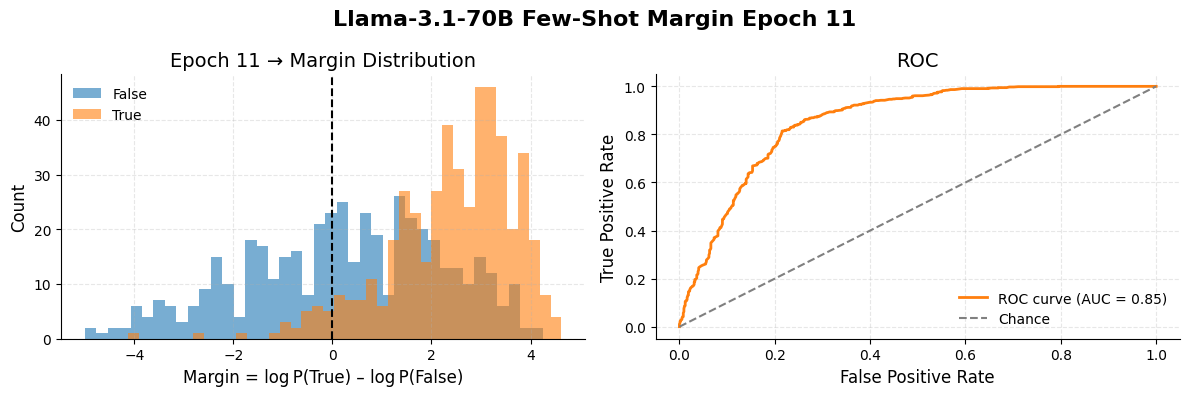

Epoch 11: trained on 8 samples → loss=0.0033


100%|██████████| 24/24 [03:26<00:00,  8.59s/it]


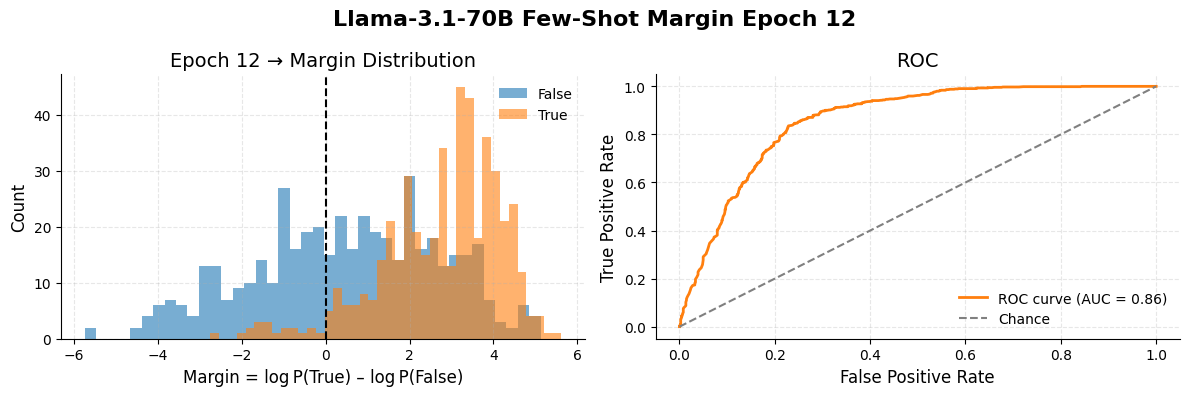

Epoch 12: trained on 8 samples → loss=0.0152


100%|██████████| 24/24 [03:24<00:00,  8.53s/it]


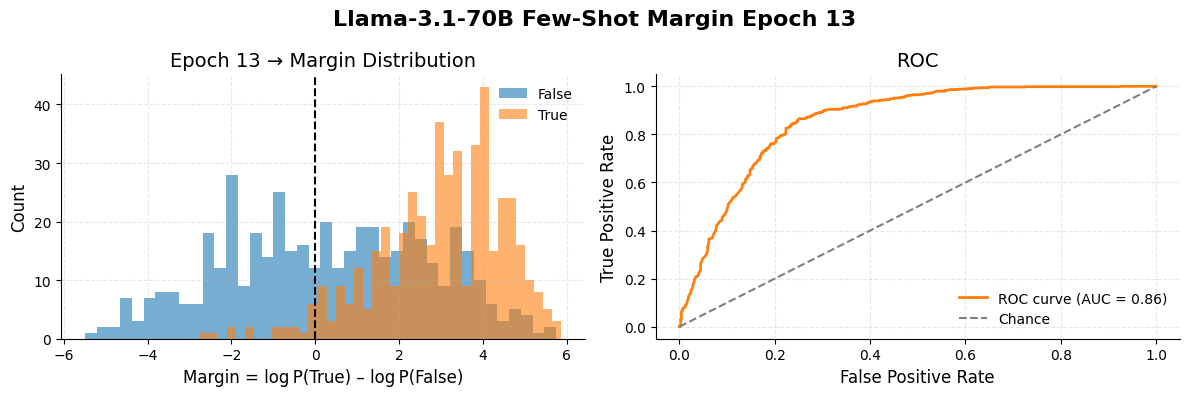

Epoch 13: trained on 8 samples → loss=0.0008


100%|██████████| 24/24 [03:25<00:00,  8.56s/it]


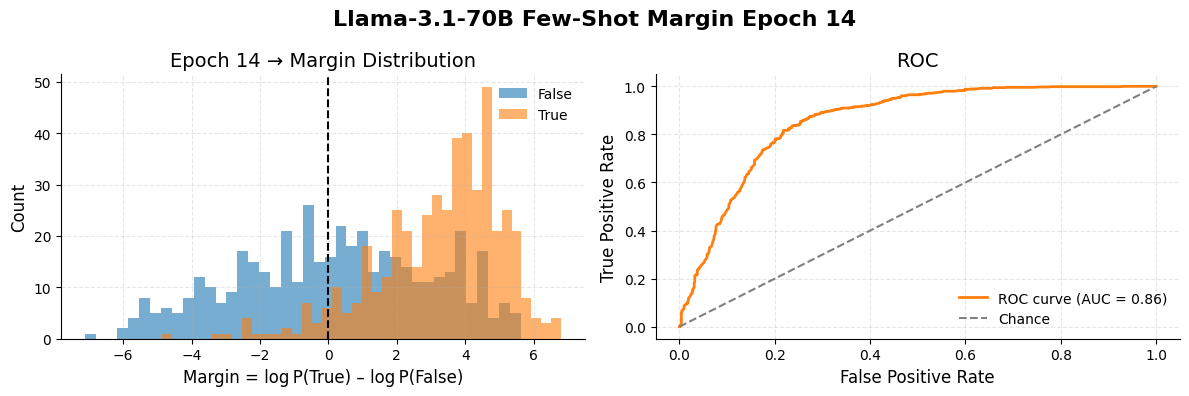

Epoch 14: trained on 8 samples → loss=0.0002


100%|██████████| 24/24 [03:24<00:00,  8.54s/it]


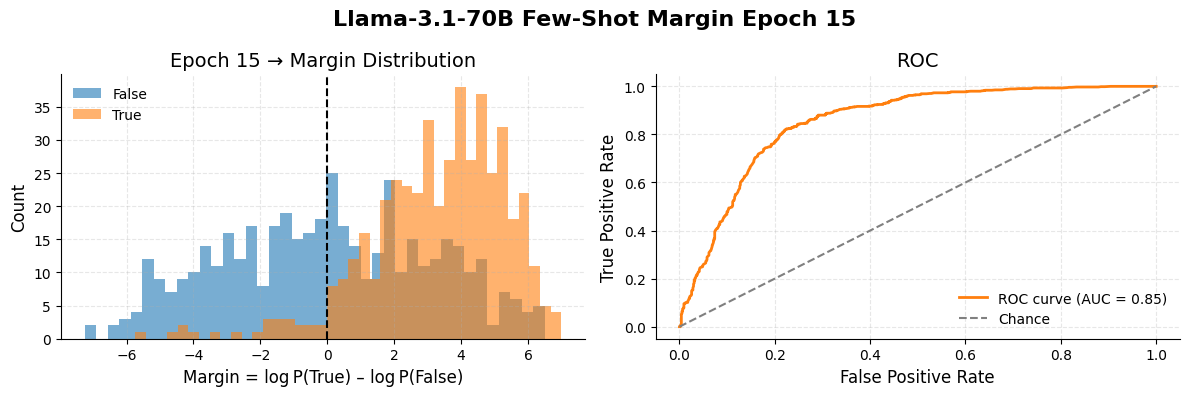

Epoch 15: trained on 8 samples → loss=0.5562


100%|██████████| 24/24 [03:25<00:00,  8.55s/it]


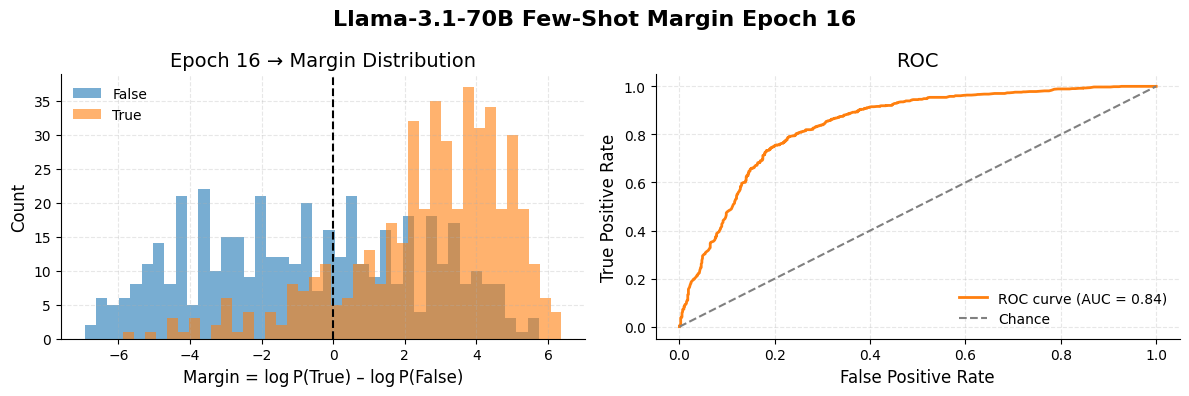

Epoch 16: trained on 8 samples → loss=0.0059


100%|██████████| 24/24 [03:25<00:00,  8.57s/it]


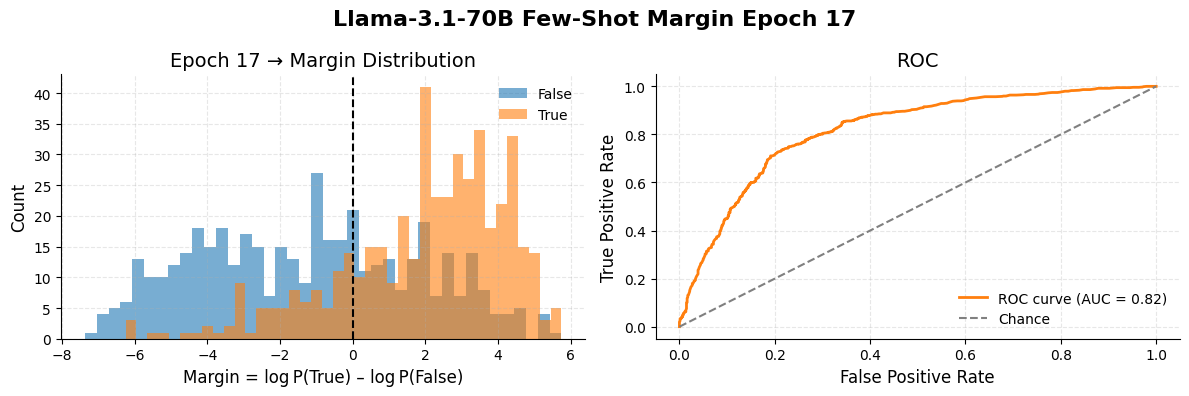

Epoch 17: trained on 8 samples → loss=0.0004


100%|██████████| 24/24 [03:24<00:00,  8.54s/it]


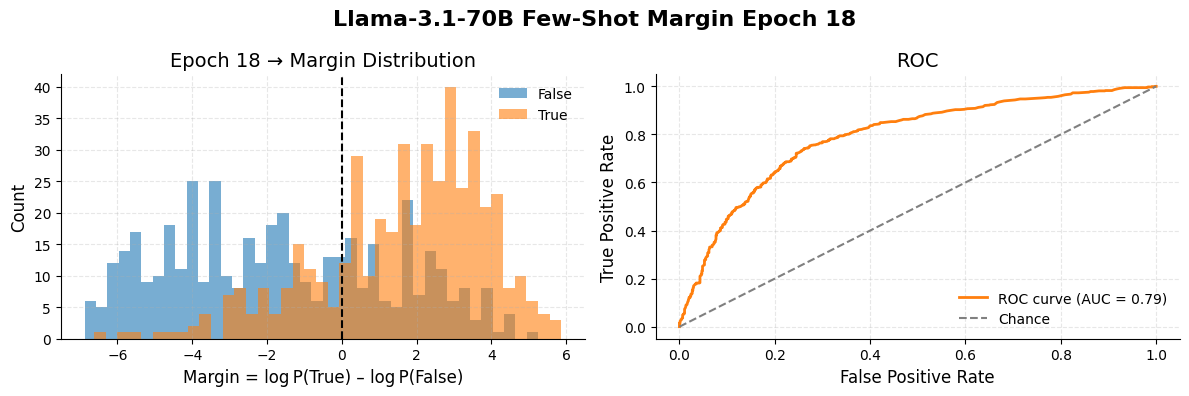

Epoch 18: trained on 8 samples → loss=0.0101


100%|██████████| 24/24 [03:25<00:00,  8.55s/it]


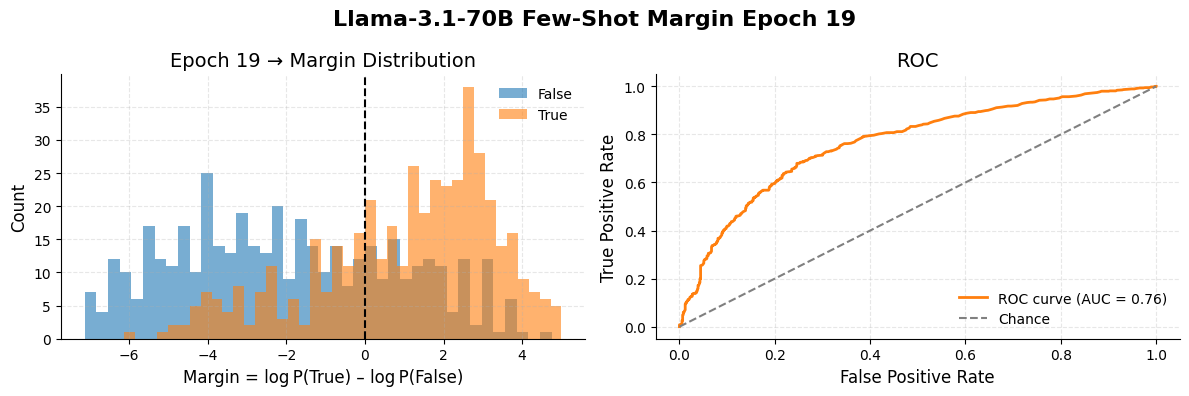

Epoch 19: trained on 8 samples → loss=0.0067


100%|██████████| 24/24 [03:25<00:00,  8.55s/it]


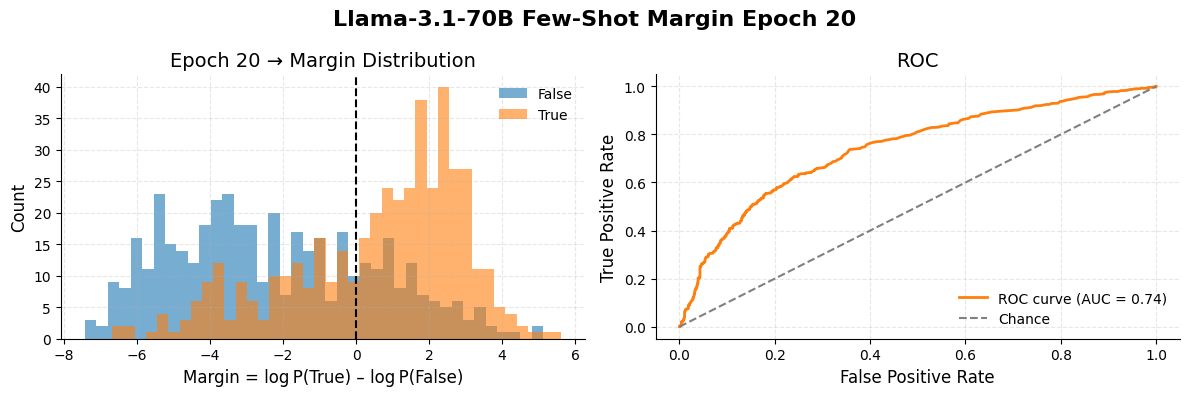

Epoch 20: trained on 8 samples → loss=0.9739


 29%|██▊       | 4/14 [01:04<02:46, 16.65s/it]

In [ ]:
import json, random, torch, matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft        import LoraConfig, get_peft_model, TaskType
from accelerate  import Accelerator

# ── CONFIG ─────────────────────────────────────────────────────────────────────
MODEL_NAME   = "/workspace/huggingface_cache/models--meta-llama--Llama-3.1-70B/snapshots/349b2ddb53ce8f2849a6c168a81980ab25258dac"
TRAIN_PATH   = "data/train_gsm8k_preference.json"
TEST_PATH    = "data/test_gsm8k_preference.json"
TRAIN_SUBSET = 1024      # how many GSM8K items to use
LR           = 5e-5      # learning rate
RANK         = 128       # LoRA rank
K            = 4         # bottom/top K per epoch
CHUNK        = 64        # scoring chunk size

# ── SETUP ──────────────────────────────────────────────────────────────────────
accelerator = Accelerator(mixed_precision="bf16")
device      = accelerator.device

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, device_map="auto", torch_dtype=torch.bfloat16
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

lora_cfg = LoraConfig(
    task_type     = TaskType.CAUSAL_LM,
    inference_mode= False,
    r             = RANK,
    lora_alpha    = 64,
    lora_dropout  = 0.0,
    target_modules= ["q_proj","v_proj"],
)
model = get_peft_model(model, lora_cfg)

# token‑ids for " True"/" False"
true_id, false_id = [
    tokenizer(t, add_special_tokens=False).input_ids[0]
    for t in (" True"," False")
]

# ── PROMPT TEMPLATE ───────────────────────────────────────────────────────────
template = (
    "Question: {question}\n"
    "Claim: {answer}\n"
    "I think this claim is"
)

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
raw_train = json.load(open(TRAIN_PATH))
train_data= raw_train[:TRAIN_SUBSET]
all_prompts = [
    template.format(question=ex["question"], answer=ex["choice"])
    for ex in train_data
]

raw_test     = json.load(open(TEST_PATH))
test_prompts = [
    template.format(question=ex["question"], answer=ex["choice"])
    for ex in raw_test
]
test_labels  = [1 if ex["label"] else 0 for ex in raw_test]

# pools for random demo selection
true_pool  = [ex for ex in train_data if ex["label"]]
false_pool = [ex for ex in train_data if not ex["label"]]

# wrap optimizer & model
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
model, optimizer = accelerator.prepare(model, optimizer)

# ── UTILS ─────────────────────────────────────────────────────────────────────
def chunk_score(prompts):
    """Returns list of (logP(True)-logP(False)) for each prompt."""
    margins = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(prompts), CHUNK)):
            chunk = prompts[i:i+CHUNK]
            enc = tokenizer(
                chunk, return_tensors="pt",
                padding=True, truncation=True, max_length=1024
            ).to(device)
            logits  = model(**enc).logits
            lengths = enc.attention_mask.sum(dim=1)
            last    = logits[torch.arange(len(chunk)), lengths-1]
            logp    = torch.log_softmax(last, dim=-1)
            margins.extend((logp[:,true_id] - logp[:,false_id]).cpu().tolist())
            del enc, logits, last, logp, lengths
            torch.cuda.empty_cache()
    return margins

# ── EPOCH LOOP ────────────────────────────────────────────────────────────────
unused = set(range(len(all_prompts)))
epoch  = 1

while len(unused) >= 2*K:
    model.train()

    # 1) build few‑shot+zero‑shot prompts in *index order*
    valid_idxs = sorted(unused)
    margin_prompts = []
    for idx in tqdm(valid_idxs):
        ex = train_data[idx]
        # randomly pick one demo from true/false pool, avoiding same consistency_id:
        pool = (true_pool if random.random()<0.5 else false_pool)
        demo = random.choice(pool)
        while demo["consistency_id"] == ex["consistency_id"]:
            demo = random.choice(pool)
        # render that demo with its label
        demo_p = (
            template.format(question=demo["question"], answer=demo["choice"])
            + (" True" if demo["label"] else " False")
        )
        # then the real zero‑shot prompt
        zero_p = all_prompts[idx]
        margin_prompts.append(f"{demo_p}\n\n{zero_p}")

    # 2) score margins
    margins = chunk_score(margin_prompts)

    # 3) PLOT histogram + AUROC
    # — histogram of GT-labelled margins —
    m_true  = [m for (i,m) in zip(valid_idxs, margins) if train_data[i]["label"]]
    m_false = [m for (i,m) in zip(valid_idxs, margins) if not train_data[i]["label"]]

    # — ROC on TEST SET (zero‑shot) —
    test_margins = chunk_score(test_prompts)
    fpr, tpr, _  = roc_curve(test_labels, test_margins)
    roc_auc      = auc(fpr, tpr)

    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))

    # left histogram
    ax1.hist(m_false, bins=40, alpha=0.6, label="False", color="#1f77b4")
    ax1.hist(m_true,  bins=40, alpha=0.6, label="True",  color="#ff7f0e")
    ax1.axvline(0, color="k", linestyle="--", lw=1.5)
    ax1.set_title(f"Epoch {epoch} → Margin Distribution", fontsize=14)
    ax1.set_xlabel("Margin = log P(True) – log P(False)", fontsize=12)
    ax1.set_ylabel("Count", fontsize=12)
    ax1.legend(frameon=False)
    ax1.grid(linestyle="--", alpha=0.3)
    for side in ("top","right"): ax1.spines[side].set_visible(False)

    # right ROC
    ax2.plot(fpr, tpr, color="#ff7f0e", lw=2,
             label=f"ROC curve (AUC = {roc_auc:.2f})")
    ax2.plot([0,1],[0,1], color="gray", lw=1.5, linestyle="--", label="Chance")
    ax2.set_title("ROC", fontsize=14)
    ax2.set_xlabel("False Positive Rate", fontsize=12)
    ax2.set_ylabel("True Positive Rate", fontsize=12)
    ax2.legend(frameon=False, loc="lower right")
    ax2.grid(linestyle="--", alpha=0.3)
    for side in ("top","right"): ax2.spines[side].set_visible(False)

    fig.suptitle(f"Llama‑3.1‑70B Few‑Shot Margin Epoch {epoch}", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.show()

    # 4) select bottom K / top K by margin
    pairs      = sorted(zip(valid_idxs, margins), key=lambda x: x[1])
    bottom_idx = [i for i,_ in pairs[:K]]
    top_idx    = [i for i,_ in pairs[-K:]]

    # 5) fine‑tune on their zero‑shot prompts
    batch_ps, batch_ls = [], []
    for i in bottom_idx:
        batch_ps.append(all_prompts[i]); batch_ls.append(0); unused.remove(i)
    for i in top_idx:
        batch_ps.append(all_prompts[i]); batch_ls.append(1); unused.remove(i)

    enc = tokenizer(
        batch_ps, return_tensors="pt",
        padding=True, truncation=True, max_length=1024
    ).to(device)
    logits      = model(**enc).logits
    lengths     = enc.attention_mask.sum(dim=1)
    last_logits = logits[torch.arange(len(batch_ps)), lengths-1]
    l_false     = last_logits[:, false_id]
    l_true      = last_logits[:, true_id]
    pair_logits = torch.stack([l_false, l_true], dim=1)
    gold        = torch.tensor(batch_ls, device=device)

    loss = F.cross_entropy(pair_logits, gold)
    accelerator.backward(loss)
    optimizer.step(); optimizer.zero_grad()
    print(f"Epoch {epoch}: trained on {2*K} samples → loss={loss.item():.4f}")

    epoch += 1
